In [32]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv(r'C:\Users\Hrugved\OneDrive\Desktop\Product-Pricing_Analysis\data\amazon.csv')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   product_id           1465 non-null   str  
 1   product_name         1465 non-null   str  
 2   category             1465 non-null   str  
 3   discounted_price     1465 non-null   str  
 4   actual_price         1465 non-null   str  
 5   discount_percentage  1465 non-null   str  
 6   rating               1465 non-null   str  
 7   rating_count         1463 non-null   str  
 8   about_product        1465 non-null   str  
 9   user_id              1465 non-null   str  
 10  user_name            1465 non-null   str  
 11  review_id            1465 non-null   str  
 12  review_title         1465 non-null   str  
 13  review_content       1465 non-null   str  
 14  img_link             1465 non-null   str  
 15  product_link         1465 non-null   str  
dtypes: str(16)
memory usage: 183.3 KB


In [7]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='str')

In [8]:
df.head(2)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...


In [9]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

# Data Cleaning

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df['discounted_price'] = df['discounted_price'].astype(str).str.replace('₹', '').str.replace(',', '')
df['discounted_price'] = pd.to_numeric(df['discounted_price'], errors='coerce')

df['actual_price'] = df['actual_price'].astype(str).str.replace('₹', '').str.replace(',', '')
df['actual_price'] = pd.to_numeric(df['actual_price'], errors='coerce')

In [12]:
df['discount_percentage'] = df['discount_percentage'].astype(str).str.replace('%', '')
df['discount_percentage'] = pd.to_numeric(df['discount_percentage'], errors='coerce')

In [13]:
df['product_name'] = df['product_name'].str.strip()
df['category'] = df['category'].str.strip()

In [14]:
# Creating new columns for discount amount and calculated discount percentage
df['discount_amount'] = df['actual_price'] - df['discounted_price']
df['discount_calc'] = (df['discount_amount'] / df['actual_price']) * 100

In [15]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   str    
 1   product_name         1465 non-null   str    
 2   category             1465 non-null   str    
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   int64  
 6   rating               1465 non-null   str    
 7   rating_count         1463 non-null   str    
 8   about_product        1465 non-null   str    
 9   user_id              1465 non-null   str    
 10  user_name            1465 non-null   str    
 11  review_id            1465 non-null   str    
 12  review_title         1465 non-null   str    
 13  review_content       1465 non-null   str    
 14  img_link             1465 non-null   str    
 15  product_link         1465 non-null   str    
 16 

,discounted_price,actual_price,discount_percentage,discount_amount,discount_calc
count,1465.000000,1465.000000,1465.000000,1465.000000,1465.000000
mean,3125.310874,5444.990635,47.691468,2319.679761,47.684924
std,6944.304394,10874.826864,21.635905,4604.473790,21.636267
min,39.000000,39.000000,0.000000,0.000000,0.000000
25%,325.000000,800.000000,32.000000,371.000000,32.001280
50%,799.000000,1650.000000,50.000000,800.000000,50.016672
75%,1999.000000,4295.000000,63.000000,1953.000000,62.885714
max,77990.000000,139900.000000,94.000000,61910.000000,94.118824


### Data Cleaning

- Removed duplicates and handled missing values  
- Converted price and discount columns to numeric format  
- Cleaned rating and review-related fields  
- Created new features like discount amount for better analysis  

In [16]:
category_counts = df['category'].value_counts()

In [17]:
category_counts

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                                          233
Electronics|WearableTechnology|SmartWatches                                                                                 76
Electronics|Mobiles&Accessories|Smartphones&BasicMobiles|Smartphones                                                        68
Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions                                                               63
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                                                52
                                                                                                                          ... 
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|RotiMakers                                                        1
Home&Kitchen|Heating,Cooling&AirQuality|Parts&Accessories|FanParts&Accessories                        

# Category Analysis

In [18]:
df.groupby('category')['rating_count'].sum().sort_values(ascending=False)

category
Electronics|Headphones,Earbuds&Accessories|Headphones|On-Ear                                            97,1751,07,15133,58460,02613,79742,77597,17491...
Computers&Accessories|NetworkingDevices|NetworkAdapters|BluetoothAdapters                                                                          95,116
Electronics|Cameras&Photography|SecurityCameras|DomeCameras                                                                   93,1121,8803,60644,6965,554
Computers&Accessories|Components|InternalSolidStateDrives                                                                                92,9253,0292,515
Computers&Accessories|Accessories&Peripherals|LaptopAccessories|Bags&Sleeves|LaptopSleeves&Slipcases                     9,94011,3309,7012,8681,09222,860
                                                                                                                              ...                        
Electronics|Mobiles&Accessories|MobileAccessories|Mounts|HandlebarM

### Category Analysis Insights

- The dataset is dominated by a few key categories, indicating that Amazon’s product listings are concentrated in specific segments.
- Categories with higher product counts suggest stronger market demand or seller competition.
- Some categories have very low representation, which may indicate niche markets or untapped opportunities.

# Top Products

In [19]:
df.sort_values(by = "rating_count" , ascending = False)[['product_name','rating_count']].head(10)

,product_name,rating_count
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,992
750,Eveready Red 1012 AAA Batteries - Pack of 10,989
977,Sennheiser CX 80S in-Ear Wired Headphones with...,"98,250"
1059,Pigeon 1.5 litre Hot Kettle and Stainless Stee...,976
151,Zoul USB Type C Fast Charging 3A Nylon Braided...,974
32,Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...,974
823,Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...,974
536,boAt Rockerz 400 Bluetooth On Ear Headphones W...,"97,175"
918,boAt Rockerz 400 Bluetooth On Ear Headphones W...,"97,174"
1165,Kitchenwell 18Pc Plastic Food Snack Bag Pouch ...,97


### Product Popularity Insights

- Products with the highest rating_count are the most popular and have strong customer engagement.
- High review count indicates higher trust and visibility among customers.
- These products can be considered best-sellers or highly demanded items in their category.

# Highest Rated Products

In [20]:
df.sort_values(by = "rating" , ascending = False)[['product_name','rating']].head(10)

,product_name,rating
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,|
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
1201,"Oratech Coffee Frother electric, milk frother ...",4.8
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7
1388,Campfire Spring Chef Prolix Instant Portable W...,4.7
1275,Multifunctional 2 in 1 Electric Egg Boiling St...,4.7


### Rating Insights

- Highly rated products reflect strong customer satisfaction and product quality.
- However, some high-rated products may have low rating_count, making them less reliable indicators of overall performance.
- A combination of high rating and high rating_count is a better measure of product success.

# Pricing & Discount Analysis

In [21]:
df[['actual_price','discounted_price']].describe()

,actual_price,discounted_price
count,1465.000000,1465.000000
mean,5444.990635,3125.310874
std,10874.826864,6944.304394
min,39.000000,39.000000
25%,800.000000,325.000000
50%,1650.000000,799.000000
75%,4295.000000,1999.000000
max,139900.000000,77990.000000


In [22]:
df.sort_values(by = 'discount_percentage', ascending = False)[['product_name','discount_percentage']].head(5)

,product_name,discount_percentage
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
364,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91


### Pricing Insights

- There is a wide range between actual_price and discounted_price, indicating aggressive discounting strategies.
- Higher-priced products do not necessarily guarantee better ratings or popularity.
- Mid-range products often show balanced performance in terms of ratings and engagement.

### Discount Insights

- Products with the highest discount_percentage are often used to attract customers and boost sales.
- However, high discounts do not always correlate with high ratings or popularity.
- This suggests that pricing alone is not the only factor influencing customer satisfaction.

# Do higher-priced products actually deliver better customer satisfaction?

In [23]:
import re

def clean_numeric(col):
    return pd.to_numeric(
        col.astype(str).str.replace(r'[^\d\.]', '', regex=True),
        errors='coerce'
    )

df['rating'] = clean_numeric(df['rating'])
df['rating_count'] = clean_numeric(df['rating_count'])
df['actual_price'] = clean_numeric(df['actual_price'])
df['discounted_price'] = clean_numeric(df['discounted_price'])
df['discount_percentage'] = clean_numeric(df['discount_percentage'])

In [24]:
df[['rating', 'rating_count']].corr()


,rating,rating_count
rating,1.000000,0.102235
rating_count,0.102235,1.000000


### The correlation between rating and rating count is 0.102235, indicating a weak positive relationship. This suggests that better-rated products does not necessarily tend to attract more customer attention.

# Do heavy discounts negatively impact perceived product quality?

In [25]:
df[['actual_price', 'rating']].corr()

,actual_price,rating
actual_price,1.000000,0.121642
rating,0.121642,1.000000


### The correlation between rating and rating count is 0.122467, indicating a weak positive relationship. This suggests that higher priced products do not necessarily tend to attract more customer satisfaction.

# Do discounts actually drive product popularity?

In [26]:
df[['discount_percentage', 'rating_count']].corr()

,discount_percentage,rating_count
discount_percentage,1.000000,0.011691
rating_count,0.011691,1.000000


# Which products offer the best value for money?

In [27]:
df[(df['rating'] > 4) & (df['discount_percentage'] > 50)][
    ['product_name', 'rating', 'discount_percentage']
].head(10)

,product_name,rating,discount_percentage
0,Wayona Nylon Braided USB to Lightning Fast Cha...,4.2,64
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,4.2,53
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,4.2,61
6,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",4.1,65
10,Portronics Konnect L POR-1081 Fast Charging 3A...,4.3,55
11,boAt Rugged v3 Extra Tough Unbreakable Braided...,4.2,63
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,4.4,69
13,Portronics Konnect CL 20W POR-1067 Type-C to 8...,4.2,61
14,Portronics Konnect L 1.2M POR-1401 Fast Chargi...,4.1,60
18,"boAt Type C A325 Tangle-free, Sturdy Type C Ca...",4.1,60


In [28]:
df[['rating','discount_percentage']].corr()

,rating,discount_percentage
rating,1.000000,-0.155375
discount_percentage,-0.155375,1.000000


### The correlation between rating and discount_percentage is -0.155375, indicating a weak negative relationship. This suggests that lower discounted products inversely affect the rating of a product.

# Rating Distribution plot

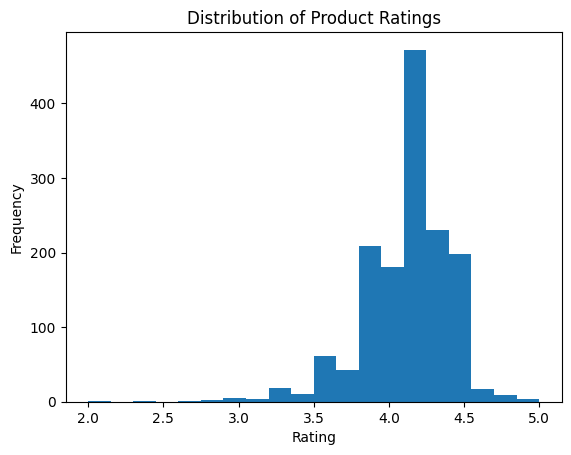

In [34]:
df['rating'].plot(kind='hist', bins=20)
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

### The majority of products are concentrated in the higher rating range (around 3.5–5), indicating generally positive customer feedback.Very few products fall into the low-rating category, suggesting overall good product quality  


# Price vs Rating Plot

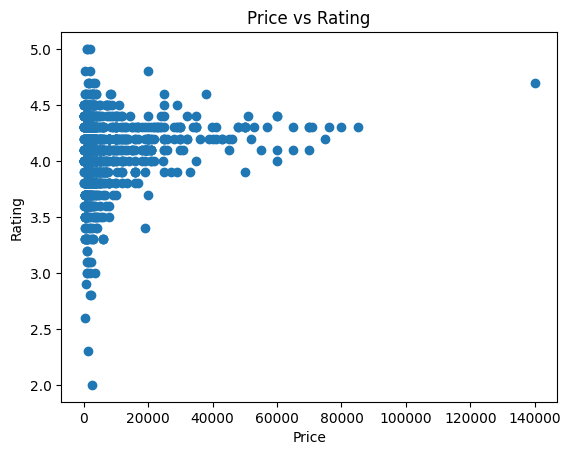

In [35]:
plt.scatter(df['actual_price'], df['rating'])
plt.xlabel('Price')
plt.ylabel('Rating')
plt.title('Price vs Rating')
plt.show()

### The scatter plot shows no strong visible relationship between price and rating.This indicates that higher-priced products do not necessarily provide better customer satisfaction  

# Discount vs Popularity

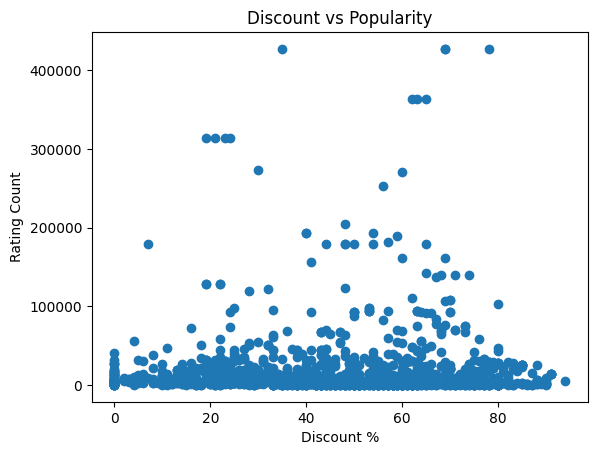

In [36]:
plt.scatter(df['discount_percentage'], df['rating_count'])
plt.xlabel('Discount %')
plt.ylabel('Rating Count')
plt.title('Discount vs Popularity')
plt.show()

### Products with higher discounts tend to show slightly higher engagement (rating count), though the relationship is not very strong.This suggests that discounts may help attract attention but are not the only factor influencing popularity  


# Top categories

C:\Users\Hrugved\AppData\Local\Temp\ipykernel_11480\312885725.py:3: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


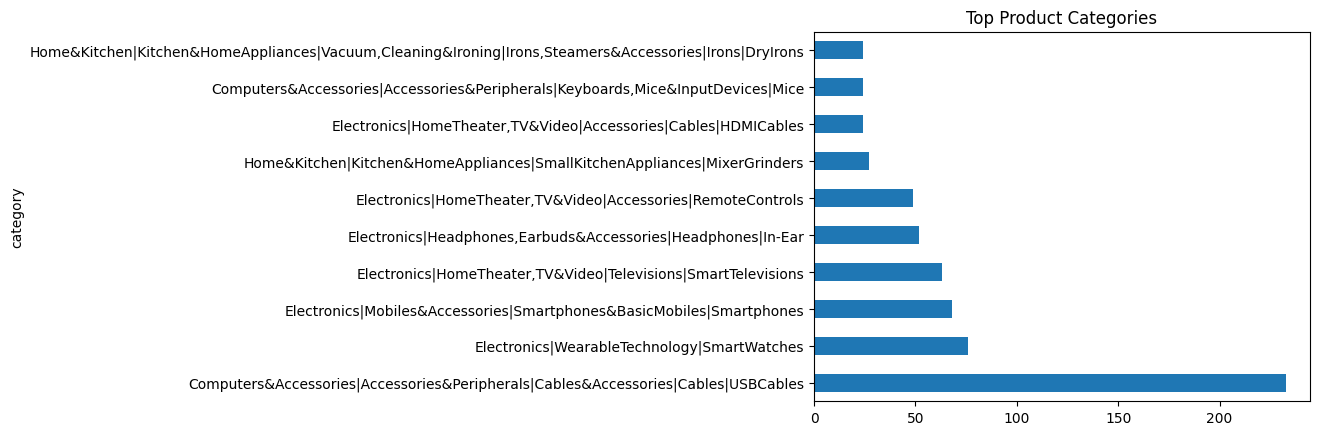

In [38]:
df['category'].value_counts().head(10).plot(kind='barh')
plt.title('Top Product Categories')
plt.tight_layout()
plt.show()

### Computers & Accessories, Cables & Accessories are the topmost category of product followed by Electronic Products such as Mobiles & Accesories, Smartwatches.

# Rating vs Categories

C:\Users\Hrugved\AppData\Local\Temp\ipykernel_11480\4252460558.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


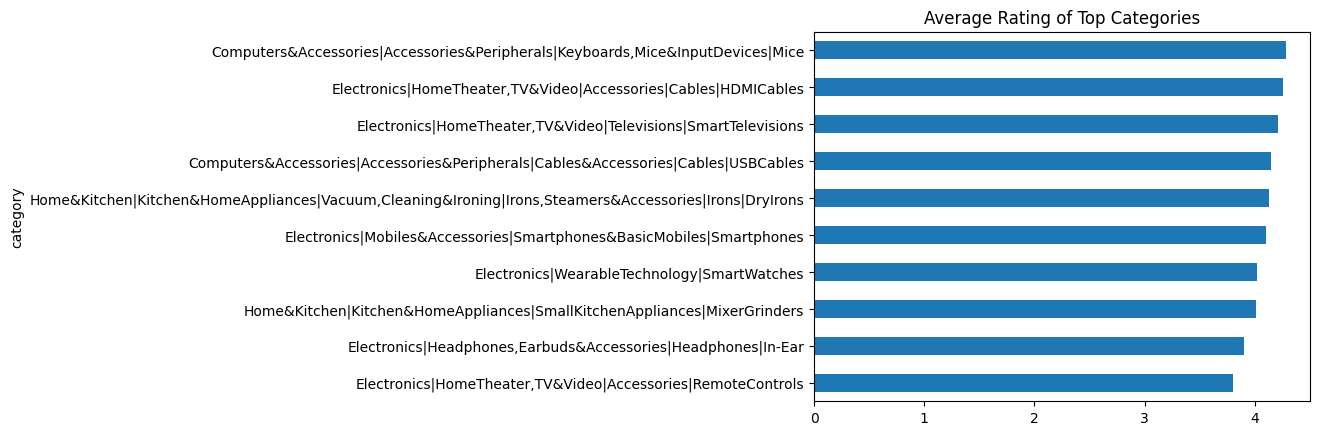

In [ ]:
top_categories = df['category'].value_counts().head(10).index
df[df['category'].isin(top_categories)] \
.groupby('category')['rating'].mean()\
.sort_values() \
.plot(kind='barh')
plt.title('Average Rating of Top Categories')
plt.tight_layout()
plt.show()

### Computers & Accessories Category has the highest rating followed by Electronics products.